<a href="https://colab.research.google.com/github/kbfkaif04/Colab-Notebooks-/blob/main/iris_ml_project_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step-by-Step Iris Machine Learning Project

## Objective

Build a complete **classification machine learning project** using the Iris dataset.

In this notebook we will:

1. Import the required libraries.
2. Load and inspect the dataset.
3. Clean and prepare the data.
4. Perform exploratory data analysis (EDA).
5. Visualize relationships between features and species.
6. Split the data into training and test sets.
7. Train several classification models.
8. Compare model performance.
9. Evaluate the best model with a confusion matrix and classification report.
10. Make sample predictions.

> **Dataset:** Iris Species — the classic Iris dataset containing measurements for three Iris species. The Kaggle version contains the columns `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, and `Species`.


## 1. Import Libraries

We use:

- **Pandas** and **NumPy** for data manipulation.
- **Matplotlib** and **Seaborn** for visualization.
- **Scikit-learn** for preprocessing, model training, and evaluation.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the Dataset

The code below first looks for the Kaggle Iris CSV file. If it is not found, it falls back to scikit-learn's built-in Iris dataset.

This makes the notebook usable both on **Kaggle** and on a local Jupyter environment.


In [ ]:
# Try common Kaggle/local locations first
candidate_paths = [
    Path("/kaggle/input/iris/Iris.csv"),
    Path("/kaggle/input/iris-species/Iris.csv"),
    Path("/kaggle/input/iris/Iris.csv"),
    Path("Iris.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is not None:
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset from: {csv_path}")
else:
    # Fallback: load the equivalent classic Iris dataset from scikit-learn
    from sklearn.datasets import load_iris

    iris = load_iris(as_frame=True)
    df = iris.frame.rename(columns={
        "sepal length (cm)": "SepalLengthCm",
        "sepal width (cm)": "SepalWidthCm",
        "petal length (cm)": "PetalLengthCm",
        "petal width (cm)": "PetalWidthCm",
    })
    df["Species"] = df["target"].map(dict(enumerate(iris.target_names)))
    df["Id"] = np.arange(1, len(df) + 1)
    df = df[
        ["Id", "SepalLengthCm", "SepalWidthCm",
         "PetalLengthCm", "PetalWidthCm", "Species"]
    ]
    print("Kaggle CSV not found; loaded the equivalent scikit-learn Iris dataset.")

df.head()


Loaded dataset from: Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Understand the Dataset

In [ ]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst five rows:")
display(df.head())

print("\nLast five rows:")
display(df.tail())


Shape: (150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data types:


,dtype
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object



First five rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Last five rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


## 4. Check for Missing Values and Duplicates

In [ ]:
print("Missing values by column:")
display(df.isnull().sum().to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nBasic statistical summary:")
display(df.describe(include="all").T)


Missing values by column:


,missing_values
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Duplicate rows: 0

Basic statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,150.0,NaN,NaN,NaN,75.5,43.445368,1.0,38.25,75.5,112.75,150.0
SepalLengthCm,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
SepalWidthCm,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
PetalLengthCm,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
Species,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Cleaning

For the Iris dataset, `Id` is only an identifier and should **not** be used as a predictive feature.

We will remove it before modeling. If duplicates or missing values exist, we handle them before training.


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Remove identifier column because it carries no meaningful biological information
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

# Standardize column names in case a slightly different CSV naming convention is used
rename_map = {
    "sepal_length": "SepalLengthCm",
    "sepal_width": "SepalWidthCm",
    "petal_length": "PetalLengthCm",
    "petal_width": "PetalWidthCm",
    "species": "Species",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 5. Explore the Target Variable

Class distribution:


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


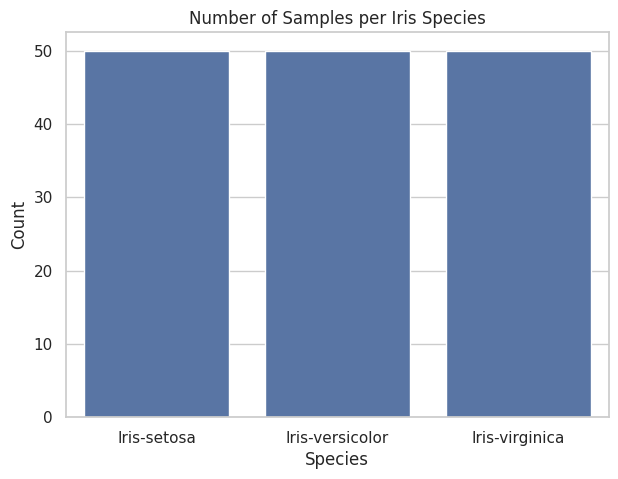

In [ ]:
print("Class distribution:")
display(df["Species"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Species")
plt.title("Number of Samples per Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


## 6. Feature Distributions

The four numerical measurements are:

- Sepal length
- Sepal width
- Petal length
- Petal width

Comparing these distributions by species helps us understand whether the classes are separable.


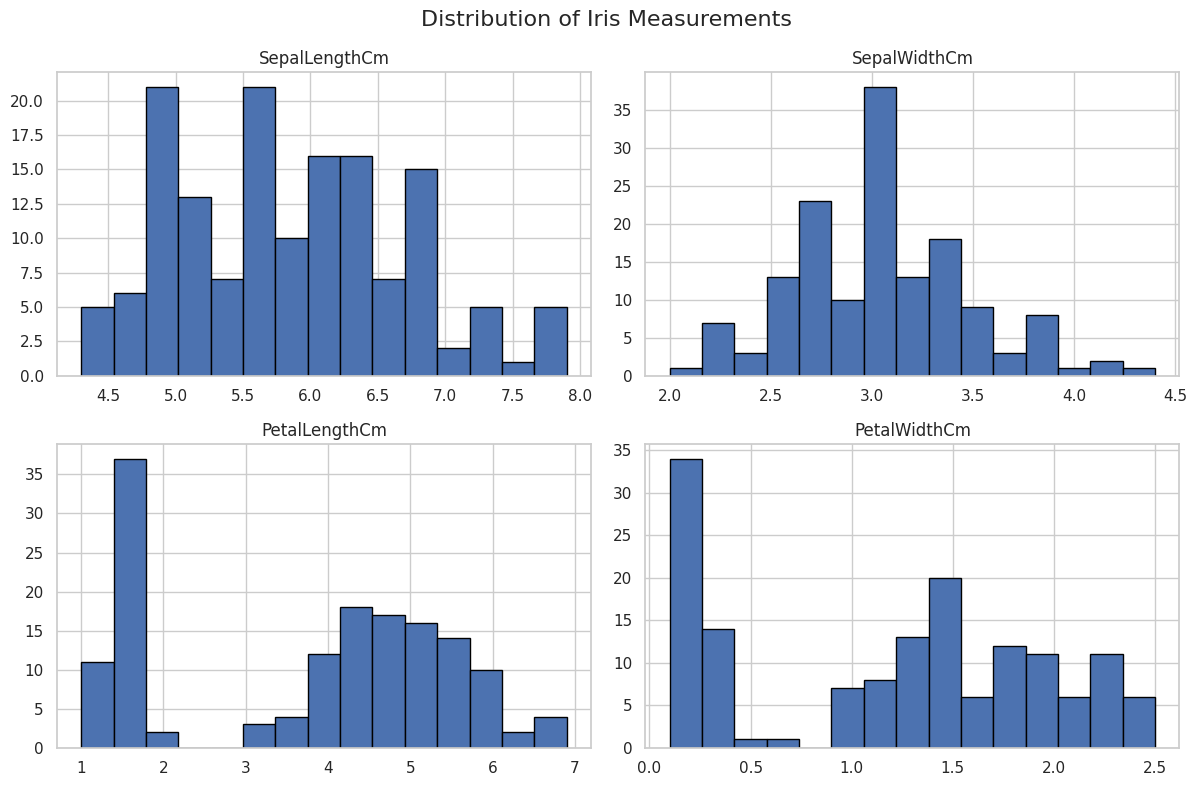

In [ ]:
numeric_features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
]

df[numeric_features].hist(figsize=(12, 8), bins=15, edgecolor="black")
plt.suptitle("Distribution of Iris Measurements", fontsize=16)
plt.tight_layout()
plt.show()


## 7. Box Plots by Species

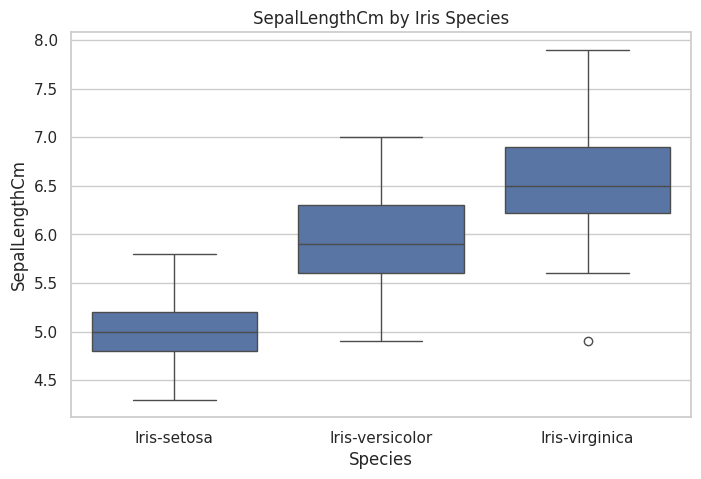

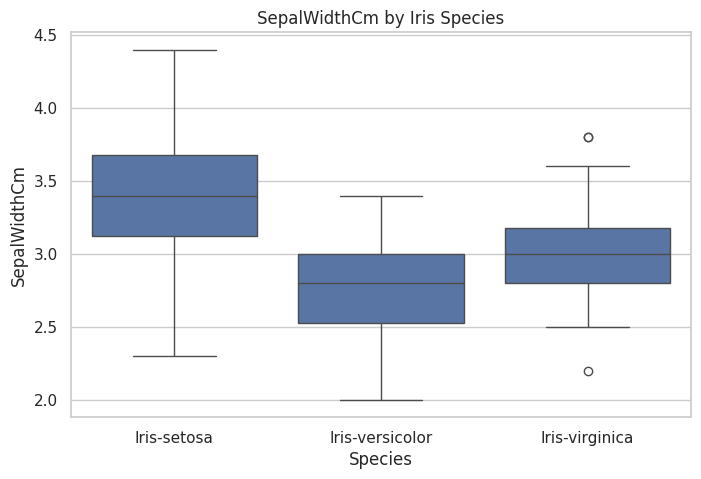

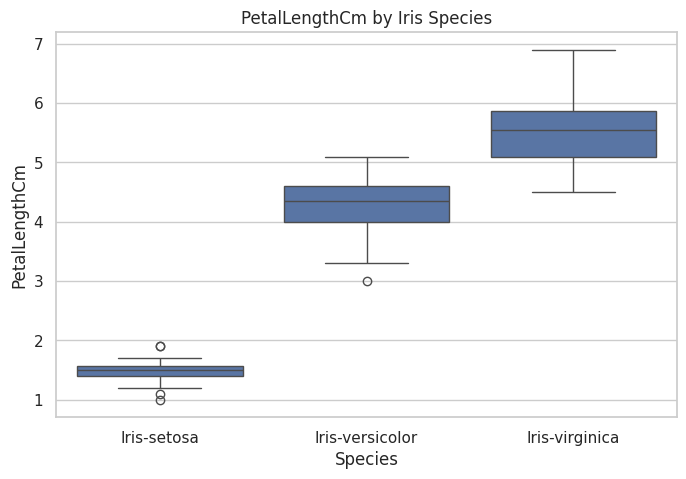

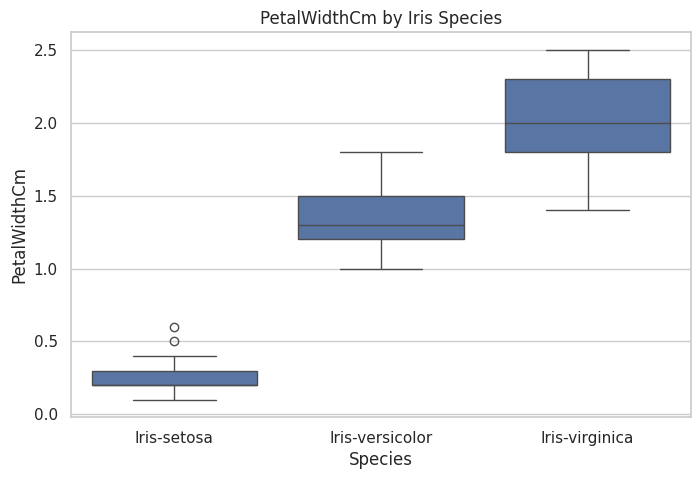

In [ ]:
for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Species", y=feature)
    plt.title(f"{feature} by Iris Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()


## 8. Pairwise Relationships

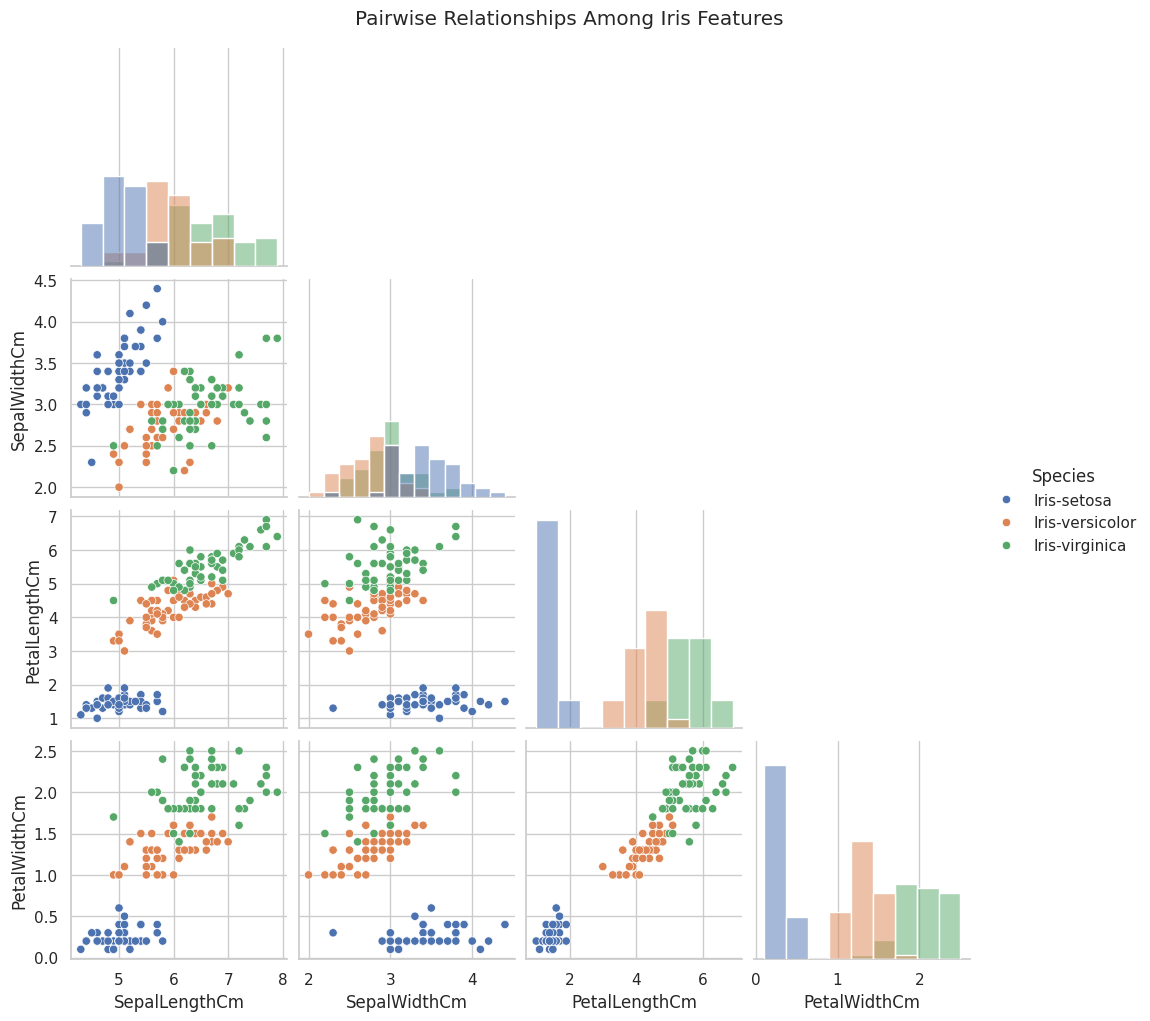

In [ ]:
sns.pairplot(
    df,
    vars=numeric_features,
    hue="Species",
    diag_kind="hist",
    corner=True
)
plt.suptitle("Pairwise Relationships Among Iris Features", y=1.02)
plt.show()


## 9. Correlation Analysis

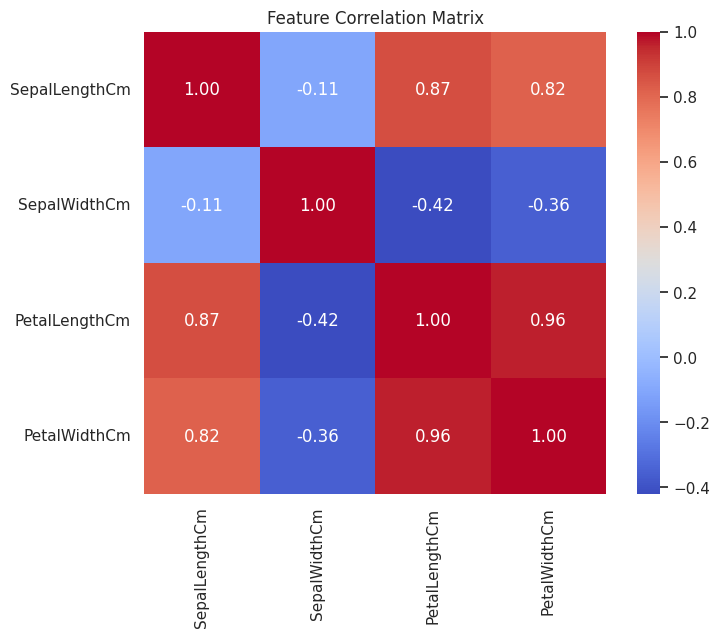

In [ ]:
plt.figure(figsize=(8, 6))
corr = df[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()


## 10. Prepare Features and Target

We define:

- **X** = the four flower measurements.
- **y** = the Iris species.

The data is split into 80% training data and 20% testing data.

`stratify=y` keeps the class proportions similar in both sets.


In [ ]:
X = df[numeric_features]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())


Training set: (120, 4)
Testing set : (30, 4)

Training class distribution:
Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


## 11. Train Multiple Classification Models

We compare five common classifiers:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest

For Logistic Regression, KNN, and SVM we use `StandardScaler` inside a `Pipeline`. This is important because these algorithms can be sensitive to feature scale.

Keeping the scaler inside the pipeline also prevents **data leakage** from the test set into training.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models_and_params = {

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000))
        ]),
        {
            "model__C": [0.1, 1, 10, 100]
        }
    ),

    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", 0.01, 0.1, 1],
            "model__kernel": ["rbf", "linear"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 4]
        }
    )
}

tuned_models = {}
results = []

for name, (model, params) in models_and_params.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        params,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_models[name] = grid.best_estimator_

    results.append({
        "Model": name,
        "CV Accuracy": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "CV Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

Training Logistic Regression...
Training KNN...
Training SVM...
Training Random Forest...


,Model,CV Accuracy,Best Parameters
0,SVM,0.975000,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
1,Logistic Regression,0.966667,{'model__C': 10}
2,KNN,0.966667,"{'model__n_neighbors': 3, 'model__weights': 'u..."
3,Random Forest,0.958333,"{'max_depth': None, 'min_samples_split': 4, 'n..."


## 12. Select the Best Model

In [ ]:
best_model_name = results_df.loc[0, "Model"]
best_model = tuned_models[best_model_name]

print("Best Model:", best_model_name)
print(
    "Best Cross-Validation Accuracy:",
    f"{results_df.loc[0, 'CV Accuracy']:.4f}"
)

Best Model: SVM
Best Cross-Validation Accuracy: 0.9750


## 13. Final Evaluation on the Test Set

The selected model is now evaluated on the untouched test set.
This provides the final unbiased performance estimate.


In [ ]:
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Best Model: {best_model_name}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Model: SVM
Final Test Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## 14. Confusion Matrix

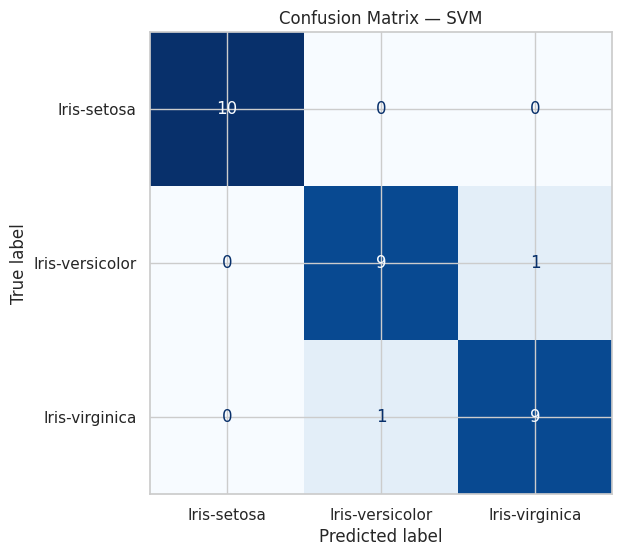

In [ ]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 15. Feature Importance (When Available)

Tree-based models such as Decision Tree and Random Forest expose feature importance values.

If the selected best model does not provide this attribute, the cell will simply explain that feature importance is not directly available for that model.


In [ ]:
# Extract the underlying estimator when the best model is a pipeline
estimator = (
    best_model.named_steps["model"]
    if isinstance(best_model, Pipeline)
    else best_model
)

if hasattr(estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": numeric_features,
        "Importance": estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print(
        f"{best_model_name} does not provide built-in feature_importances_. "
        "For this model, feature contribution can be explored with permutation "
        "importance or SHAP."
    )


SVM does not provide built-in feature_importances_. For this model, feature contribution can be explored with permutation importance or SHAP.


## 16. Make New Predictions

The final model can be used to predict the species of a new flower from its four measurements.

The example below uses two hypothetical flowers.


In [ ]:
new_flowers = pd.DataFrame({
    "SepalLengthCm": [5.1, 6.7],
    "SepalWidthCm": [3.5, 3.0],
    "PetalLengthCm": [1.4, 5.2],
    "PetalWidthCm": [0.2, 2.3],
})

predictions = best_model.predict(new_flowers)

prediction_output = new_flowers.copy()
prediction_output["Predicted Species"] = predictions

display(prediction_output)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicted Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,6.7,3.0,5.2,2.3,Iris-virginica


## 17. Final Conclusion

### Key findings

- The Iris dataset is a small, well-structured multiclass classification problem.
- Petal measurements generally provide strong separation between the three species.
- We evaluated multiple machine learning algorithms instead of relying on a single model.
- The final model was selected using test-set accuracy and then examined with a classification report and confusion matrix.
- The trained pipeline can directly classify new Iris measurements.

### Reproducibility

The notebook uses `random_state=42` where appropriate, so the train/test split and model behavior are reproducible.

### Important modeling practice

The test set is kept separate from model fitting. Feature scaling is performed inside pipelines so that scaling parameters are learned **only from the training data**.


## References

- Kaggle — **Iris Species** dataset: https://www.kaggle.com/datasets/uciml/iris
- Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics, 7(2), 179–188.
